In [ ]:
#1

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Download dataset using kagglehub
import kagglehub
import os

path = kagglehub.dataset_download("uciml/adult-census-income")
print("Path to dataset files:", path)

# Load dataset from downloaded path
df = pd.read_csv(os.path.join(path, "adult.csv"))

print("\nDataset loaded successfully!")
print(f"Shape: {df.shape}")
print(df.head())

100%|██████████| 450k/450k [00:02<00:00, 157kB/s]

Extracting files...
Path to dataset files: C:\Users\Admin\.cache\kagglehub\datasets\uciml\adult-census-income\versions\3

Dataset loaded successfully!
Shape: (32561, 15)
   age workclass  fnlwgt     education  education.num marital.status  \
0   90         ?   77053       HS-grad              9        Widowed   
1   82   Private  132870       HS-grad              9        Widowed   
2   66         ?  186061  Some-college             10        Widowed   
3   54   Private  140359       7th-8th              4       Divorced   
4   41   Private  264663  Some-college             10      Separated   

          occupation   relationship   race     sex  capital.gain  \
0                  ?  Not-in-family  White  Female             0   
1    Exec-managerial  Not-in-family  White  Female             0   
2                  ?      Unmarried  Black  Female             0   
3  Machine-op-inspct      Unmarried  White  Female             0   
4     Prof-specialty      Own-child  White  Female       

In [4]:
# Basic overview of dataset
print("=== Dataset Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Unique Values in Categorical Columns ===")
print(f"Sex:            {df['sex'].unique()}")
print(f"Income:         {df['income'].unique()}")
print(f"Marital Status: {df['marital.status'].unique()}")
print(f"Education:      {df['education'].unique()}")

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB
None

=== Missing Values ===
age               0
workclass         0
fnl

In [5]:
# Overall summary statistics of numeric columns
num_cols = ['age', 'hours.per.week', 'capital.gain', 'capital.loss']

print("=== Summary Statistics ===")
print(df[num_cols].describe())

print("\n=== Mean ===")
print(df[num_cols].mean())

print("\n=== Median ===")
print(df[num_cols].median())

print("\n=== Standard Deviation ===")
print(df[num_cols].std())

print("\n=== Minimum ===")
print(df[num_cols].min())

print("\n=== Maximum ===")
print(df[num_cols].max())

print("\nSummary statistics displayed successfully!")

=== Summary Statistics ===
                age  hours.per.week  capital.gain  capital.loss
count  32561.000000    32561.000000  32561.000000  32561.000000
mean      38.581647       40.437456   1077.648844     87.303830
std       13.640433       12.347429   7385.292085    402.960219
min       17.000000        1.000000      0.000000      0.000000
25%       28.000000       40.000000      0.000000      0.000000
50%       37.000000       40.000000      0.000000      0.000000
75%       48.000000       45.000000      0.000000      0.000000
max       90.000000       99.000000  99999.000000   4356.000000

=== Mean ===
age                 38.581647
hours.per.week      40.437456
capital.gain      1077.648844
capital.loss        87.303830
dtype: float64

=== Median ===
age               37.0
hours.per.week    40.0
capital.gain       0.0
capital.loss       0.0
dtype: float64

=== Standard Deviation ===
age                 13.640433
hours.per.week      12.347429
capital.gain      7385.292085
capital

In [6]:
# Summary statistics of age grouped by income
print("=== Age Statistics Grouped by Income ===")
print(df.groupby("income")["age"].describe())

print("\n=== Hours Per Week Grouped by Income ===")
print(df.groupby("income")["hours.per.week"].describe())

print("\n=== Mean Age by Income ===")
print(df.groupby("income")["age"].mean())

=== Age Statistics Grouped by Income ===
          count       mean        std   min   25%   50%   75%   max
income                                                             
<=50K   24720.0  36.783738  14.020088  17.0  25.0  34.0  46.0  90.0
>50K     7841.0  44.249841  10.519028  19.0  36.0  44.0  51.0  90.0

=== Hours Per Week Grouped by Income ===
          count       mean        std  min   25%   50%   75%   max
income                                                            
<=50K   24720.0  38.840210  12.318995  1.0  35.0  40.0  40.0  99.0
>50K     7841.0  45.473026  11.012971  1.0  40.0  40.0  50.0  99.0

=== Mean Age by Income ===
income
<=50K    36.783738
>50K     44.249841
Name: age, dtype: float64


In [7]:
# Summary statistics of age grouped by marital status
print("=== Age Statistics Grouped by Marital Status ===")
print(df.groupby("marital.status")["age"].describe())

print("\n=== Mean Age by Marital Status ===")
print(df.groupby("marital.status")["age"].mean())

print("\n=== Median Age by Marital Status ===")
print(df.groupby("marital.status")["age"].median())

=== Age Statistics Grouped by Marital Status ===
                         count       mean        std   min   25%   50%   75%  \
marital.status                                                                 
Divorced                4443.0  43.041639  10.400396  18.0  35.0  42.0  50.0   
Married-AF-spouse         23.0  32.478261  11.610613  19.0  26.5  30.0  35.0   
Married-civ-spouse     14976.0  43.247596  12.056002  17.0  34.0  42.0  51.0   
Married-spouse-absent    418.0  40.578947  12.397677  18.0  31.0  40.0  48.0   
Never-married          10683.0  28.150988  10.007241  17.0  21.0  25.0  32.0   
Separated               1025.0  39.354146  10.835977  18.0  31.0  38.0  46.0   
Widowed                  993.0  58.975831  12.345555  18.0  51.0  60.0  67.0   

                        max  
marital.status               
Divorced               90.0  
Married-AF-spouse      75.0  
Married-civ-spouse     90.0  
Married-spouse-absent  80.0  
Never-married          90.0  
Separated           

In [8]:
# Count number of records by category
# value_counts() counts number of records per category 
print("=== Value Counts of Marital Status ===")
print(df["marital.status"].value_counts())

print("\n=== Value Counts of Income ===")
print(df["income"].value_counts())

print("\n=== Value Counts of Sex ===")
print(df["sex"].value_counts())

print("\nValue counts displayed successfully!")

=== Value Counts of Marital Status ===
marital.status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64

=== Value Counts of Income ===
income
<=50K    24720
>50K      7841
Name: count, dtype: int64

=== Value Counts of Sex ===
sex
Male      21790
Female    10771
Name: count, dtype: int64

Value counts displayed successfully!


In [18]:
print("=== Adult Dataset Summary ===")
print(f"Total Records : {df.shape[0]}")
print(f"Total Columns : {df.shape[1]}")
print(f"Numeric Cols  : {df.select_dtypes(include='number').columns.tolist()}")
print(f"Categorical Cols: {df.select_dtypes(include='object').columns.tolist()}")

=== Adult Dataset Summary ===
Total Records : 32561
Total Columns : 15
Numeric Cols  : ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
Categorical Cols: ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country', 'income']


In [ ]:
#2

In [9]:
# Download iris dataset using kagglehub
path2 = kagglehub.dataset_download("uciml/iris")
print("Path to dataset files:", path2)

# Load dataset
iris = pd.read_csv(os.path.join(path2, "Iris.csv"))

print("\nIris Dataset loaded successfully!")
print(f"Shape: {iris.shape}")
print(iris.head())

100%|██████████| 3.60k/3.60k [00:00<00:00, 641kB/s]

Extracting files...
Path to dataset files: C:\Users\Admin\.cache\kagglehub\datasets\uciml\iris\versions\2

Iris Dataset loaded successfully!
Shape: (150, 6)
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [10]:
# Basic overview of iris dataset
print("=== Dataset Info ===")
print(iris.info())

print("\n=== Unique Species ===")
print(iris["Species"].unique())

print("\n=== Value Counts of Species ===")
print(iris["Species"].value_counts())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None

=== Unique Species ===
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']

=== Value Counts of Species ===
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [11]:
# Summary statistics of each species 
print("=== Iris-setosa ===")
setosa = iris['Species'] == 'Iris-setosa'
print(iris[setosa].describe())

print("\n=== Iris-versicolor ===")
versicolor = iris['Species'] == 'Iris-versicolor'
print(iris[versicolor].describe())

print("\n=== Iris-virginica ===")
virginica = iris['Species'] == 'Iris-virginica'
print(iris[virginica].describe())

print("\nSpecies statistics displayed successfully!")

=== Iris-setosa ===
             Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  50.00000       50.00000     50.000000      50.000000      50.00000
mean   25.50000        5.00600      3.418000       1.464000       0.24400
std    14.57738        0.35249      0.381024       0.173511       0.10721
min     1.00000        4.30000      2.300000       1.000000       0.10000
25%    13.25000        4.80000      3.125000       1.400000       0.20000
50%    25.50000        5.00000      3.400000       1.500000       0.20000
75%    37.75000        5.20000      3.675000       1.575000       0.30000
max    50.00000        5.80000      4.400000       1.900000       0.60000

=== Iris-versicolor ===
              Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count   50.00000      50.000000     50.000000      50.000000     50.000000
mean    75.50000       5.936000      2.770000       4.260000      1.326000
std     14.57738       0.516171      0.313798       0.469911    

In [12]:
# Percentile of each species
print("=== Percentile 25% ===")
print(iris.groupby("Species")["SepalLengthCm"].quantile(0.25))

print("\n=== Percentile 50% (Median) ===")
print(iris.groupby("Species")["SepalLengthCm"].quantile(0.50))

print("\n=== Percentile 75% ===")
print(iris.groupby("Species")["SepalLengthCm"].quantile(0.75))

print("\nPercentiles displayed successfully!")

=== Percentile 25% ===
Species
Iris-setosa        4.800
Iris-versicolor    5.600
Iris-virginica     6.225
Name: SepalLengthCm, dtype: float64

=== Percentile 50% (Median) ===
Species
Iris-setosa        5.0
Iris-versicolor    5.9
Iris-virginica     6.5
Name: SepalLengthCm, dtype: float64

=== Percentile 75% ===
Species
Iris-setosa        5.2
Iris-versicolor    6.3
Iris-virginica     6.9
Name: SepalLengthCm, dtype: float64

Percentiles displayed successfully!


C:\Users\Admin\AppData\Local\Temp\ipykernel_16888\3107264956.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Species', y='SepalLengthCm', data=iris, palette='pastel')
C:\Users\Admin\AppData\Local\Temp\ipykernel_16888\3107264956.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Species', y='PetalLengthCm', data=iris, palette='pastel')


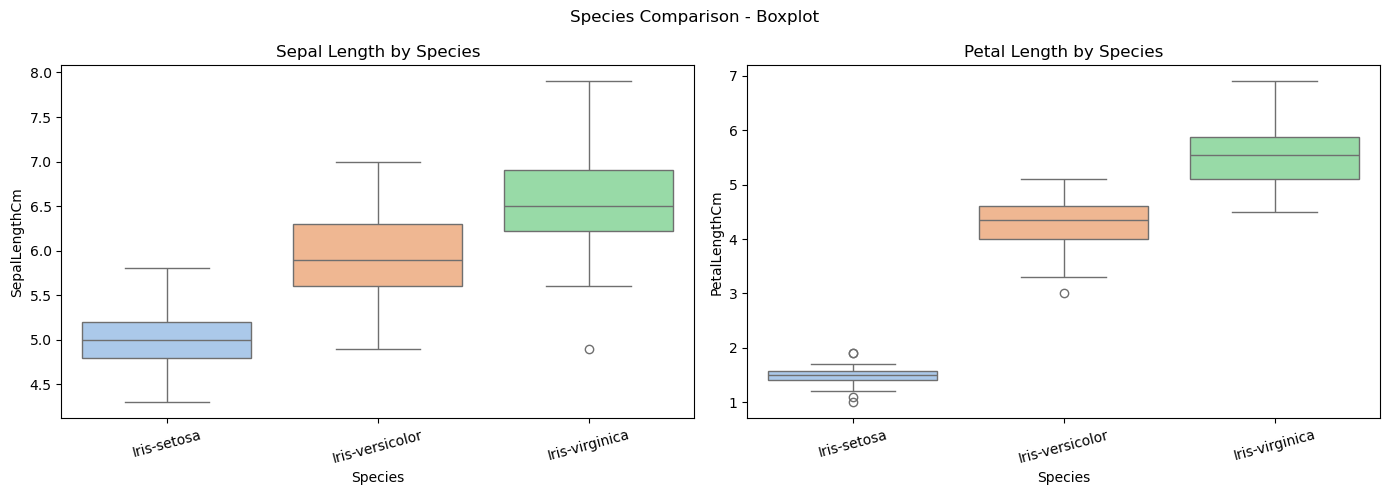

Boxplots plotted successfully!


In [13]:
# Boxplot of sepal length by species
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='Species', y='SepalLengthCm', data=iris, palette='pastel')
plt.title('Sepal Length by Species')
plt.xticks(rotation=15)

plt.subplot(1, 2, 2)
sns.boxplot(x='Species', y='PetalLengthCm', data=iris, palette='pastel')
plt.title('Petal Length by Species')
plt.xticks(rotation=15)

plt.suptitle('Species Comparison - Boxplot')
plt.tight_layout()
plt.show()
print("Boxplots plotted successfully!")

C:\Users\Admin\AppData\Local\Temp\ipykernel_16888\3389765908.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Species', y='SepalLengthCm', data=iris, palette='pastel')


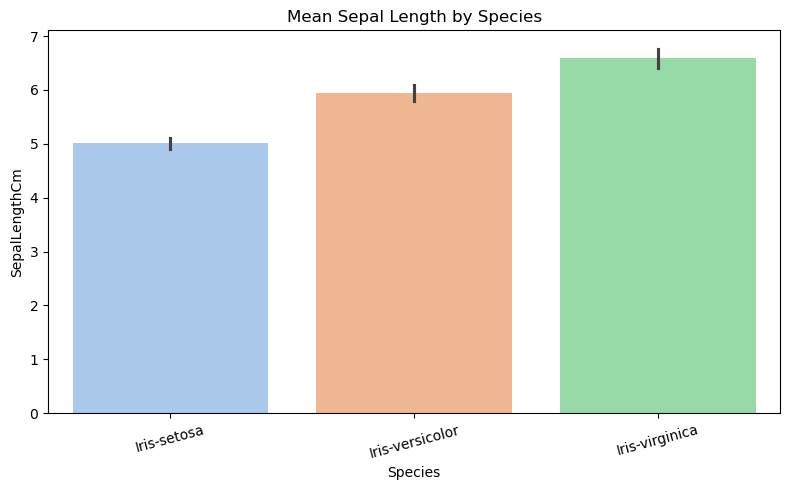

Barplot plotted successfully!


In [14]:
# Barplot of mean sepal length by species
plt.figure(figsize=(8, 5))
sns.barplot(x='Species', y='SepalLengthCm', data=iris, palette='pastel')
plt.title('Mean Sepal Length by Species')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
print("Barplot plotted successfully!")

In [17]:
print("\n=== Iris Dataset Summary ===")
print(f"Total Records : {iris.shape[0]}")
print(f"Total Columns : {iris.shape[1]}")
print(f"Species       : {iris['Species'].unique().tolist()}")



=== Iris Dataset Summary ===
Total Records : 150
Total Columns : 6
Species       : ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
